<a href="https://colab.research.google.com/github/romeofopa/DA-Projects/blob/main/Waste_Reduction_Operational_Efficiency_And_Predictive_Maintenance_In_Beverage_Company.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**WASTE REDUCTION,OPERATIONAL EFFICIENCY AND PREDICTIVE MAINTENANCE IN A BEVERAGE INDUSTRY**


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Command to tell Python to actually display the graphs
%matplotlib inline

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.2f" % x) # To supress numerical display in scientific notations


# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV


# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    make_scorer,

)

In [3]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to build linear regression_model using statsmodels
import statsmodels.api as sm

# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Importing the dataset

**EXPLORATORY DATA ANALYSIS**

# 1.1 SANITARY CHECK PRIOR TO EXPLORATORY DATA ANALYSIS

---



In [4]:
data = pd.read_csv('/content/drive/My Drive/Beverage_Waste_Dataset_Final_Updated (3).csv')

In [5]:
data.head()

,Month,Plant_ID,Production_Line,Package_Type,Production_Volume_L,Syrup_Waste_L,Container_Defect_Count,Label_Waste_Count,Can_Liner_Waste_Count,Expired_Product_L,Total_Waste_kg,Recycled_kg,Landfill_kg,Waste_Disposal_Cost_USD,Downtime_Hours,Cost_of_Poor_Quality_USD,Cost_of_Production_USD,Monthly_Profit_USD,Year,Water_Usage_L,Monthly_Downtime_Cost_USD,Machine_Failure_Count,Maintenance_Cost_USD
0,2016-01-01,TX01,Line1,Can,1063068.00,NaN,3377.00,NaN,2106.00,847.00,3453.00,3016.00,437.00,1045.62,28.30,2042.84,2126136,4252272,2016,2060753.90,27950.27,3,1701.17
1,2016-01-01,TX01,Line2,Can,1001155.00,2797.00,2538.00,NaN,1843.00,572.00,3641.00,2670.00,NaN,1105.47,15.30,2809.82,2002310,4004620,2016,2065646.62,17137.99,3,1550.15
2,2016-01-01,TX01,Line3,Bottle,963254.00,3165.00,3062.00,3757.00,NaN,697.00,4184.00,2569.00,1615.00,1186.16,25.20,3343.87,1926508,3853016,2016,1887054.50,14542.53,1,1081.97
3,2016-02-01,TX01,Line1,Can,943693.00,3176.00,3134.00,NaN,1132.00,836.00,4323.00,3252.00,1071.00,1324.50,19.20,2398.36,1887386,3774772,2016,2089794.07,18401.75,0,0.00
4,2016-02-01,TX01,Line2,Can,1114764.00,2924.00,1761.00,NaN,973.00,910.00,4093.00,2704.00,1389.00,1340.95,27.00,3730.29,2229528,4459056,2016,2426086.67,29129.05,6,8237.52


In [6]:
data.tail()

,Month,Plant_ID,Production_Line,Package_Type,Production_Volume_L,Syrup_Waste_L,Container_Defect_Count,Label_Waste_Count,Can_Liner_Waste_Count,Expired_Product_L,Total_Waste_kg,Recycled_kg,Landfill_kg,Waste_Disposal_Cost_USD,Downtime_Hours,Cost_of_Poor_Quality_USD,Cost_of_Production_USD,Monthly_Profit_USD,Year,Water_Usage_L,Monthly_Downtime_Cost_USD,Machine_Failure_Count,Maintenance_Cost_USD
2155,2025-11-01,NY06,Line2,Can,1329200.00,NaN,5295.00,NaN,1324.00,892.00,5949.00,3821.00,2128.00,1201.14,4.50,2569.36,2658400,5316800,2025,3072673.11,2938.58,4,3230.34
2156,2025-11-01,NY06,Line3,Bottle,1638439.00,4489.00,10567.00,4773.00,NaN,2661.00,7872.00,4772.00,3100.00,1963.44,23.30,3754.82,3276878,6553756,2025,3745684.45,42983.62,1,405.74
2157,2025-12-01,NY06,Line1,Can,1099894.00,3151.00,2656.00,NaN,885.00,1725.00,5212.00,4333.00,879.00,1382.27,14.90,2544.59,2199788,4399576,2025,2734561.42,27930.73,3,1388.33
2158,2025-12-01,NY06,Line2,Can,1375585.00,4083.00,2338.00,NaN,1899.00,NaN,6327.00,5221.00,1106.00,2492.92,NaN,3773.27,2751170,5502340,2025,3405601.43,NaN,2,853.44
2159,2025-12-01,NY06,Line3,Bottle,1406300.00,3296.00,5708.00,5227.00,NaN,2161.00,5953.00,4200.00,1753.00,1276.89,23.40,2994.78,2812600,5625200,2025,3176437.62,14601.36,1,886.74


#Understanding the shape of the data

In [7]:
# Checking the shape of the data
print("There are", data.shape[0],'row and',data.shape[1],'columns.')

There are 2160 row and 23 columns.


# Checking the data types of the columns for the dataset

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Month                      2160 non-null   object 
 1   Plant_ID                   2160 non-null   object 
 2   Production_Line            2160 non-null   object 
 3   Package_Type               2160 non-null   object 
 4   Production_Volume_L        2047 non-null   float64
 5   Syrup_Waste_L              2051 non-null   float64
 6   Container_Defect_Count     2067 non-null   float64
 7   Label_Waste_Count          695 non-null    float64
 8   Can_Liner_Waste_Count      1371 non-null   float64
 9   Expired_Product_L          2062 non-null   float64
 10  Total_Waste_kg             2052 non-null   float64
 11  Recycled_kg                2049 non-null   float64
 12  Landfill_kg                2056 non-null   float64
 13  Waste_Disposal_Cost_USD    2051 non-null   float

# There are 17numerical columns (14 float) 3 interger and 4 Objects Colums

---



**MISSING VALUES**

**Missing values occurs when no data is stored for the variable in an observation.Missing data are a common occurances and can have a significant effect on the conclusions that can be drawn from the data**.


**CHECKING FOR MISSING VALUES IN THE DATASET**

In [9]:
print(data.isnull().sum())

Month                           0
Plant_ID                        0
Production_Line                 0
Package_Type                    0
Production_Volume_L           113
Syrup_Waste_L                 109
Container_Defect_Count         93
Label_Waste_Count            1465
Can_Liner_Waste_Count         789
Expired_Product_L              98
Total_Waste_kg                108
Recycled_kg                   111
Landfill_kg                   104
Waste_Disposal_Cost_USD       109
Downtime_Hours                108
Cost_of_Poor_Quality_USD      111
Cost_of_Production_USD          0
Monthly_Profit_USD              0
Year                            0
Water_Usage_L                 113
Monthly_Downtime_Cost_USD     108
Machine_Failure_Count           0
Maintenance_Cost_USD            0
dtype: int64


# There are 14 Columns with missing values.


# We will threat these missing values after understanding the distributions of features in the data, the relationships that exist in the data.This will help us impute these values more effectively.

# CHECKING FOR DUPLICATE ENTRIES IN THE DATASET

In [10]:
data.duplicated().sum()

np.int64(0)

# There are no Duplicate entries

# LETS CHECK THE STATISTICAL SUMMARY OF ALL 3 LINES IN ALL 6 PLANTS IN THE DATASET.

In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Production_Volume_L,2047.00,1377912.97,310536.17,589139.00,1139081.00,1370066.00,1585654.50,2383633.00
Syrup_Waste_L,2051.00,4158.51,1233.89,1336.00,3188.00,4073.00,4981.00,8072.00
Container_Defect_Count,2067.00,5085.03,2187.62,1238.00,3456.50,4646.00,6356.00,14008.00
Label_Waste_Count,695.00,3465.50,1430.52,830.00,2336.50,3300.00,4350.50,8750.00
Can_Liner_Waste_Count,1371.00,1721.65,712.98,400.00,1132.50,1654.00,2212.00,4165.00
Expired_Product_L,2062.00,1705.77,726.56,444.00,1153.00,1610.00,2185.00,4310.00
Total_Waste_kg,2052.00,6325.43,1786.26,1979.00,4973.00,6202.50,7510.00,12366.00
Recycled_kg,2049.00,4746.71,1437.63,1314.00,3707.00,4584.00,5644.00,10129.00
Landfill_kg,2056.00,1581.23,732.39,296.00,1022.00,1447.00,2054.25,4521.00
Waste_Disposal_Cost_USD,2051.00,1824.68,654.41,461.73,1344.94,1713.46,2213.70,4833.92


# Convert Date Column to Year

In [12]:
data['Month'] = pd.to_datetime(data['Month'])
data['Year'] = data['Month'].dt.year

# Now each row will contain the year of production.

In [13]:
yearly_summary = data.groupby(['Plant_ID','Year']).describe()

print(yearly_summary)

              Month                                            \
              count                 mean                  min   
Plant_ID Year                                                   
CA02     2016    36  2016-06-16 08:00:00  2016-01-01 00:00:00   
         2017    36  2017-06-16 12:00:00  2017-01-01 00:00:00   
         2018    36  2018-06-16 12:00:00  2018-01-01 00:00:00   
         2019    36  2019-06-16 12:00:00  2019-01-01 00:00:00   
         2020    36  2020-06-16 08:00:00  2020-01-01 00:00:00   
         2021    36  2021-06-16 12:00:00  2021-01-01 00:00:00   
         2022    36  2022-06-16 12:00:00  2022-01-01 00:00:00   
         2023    36  2023-06-16 12:00:00  2023-01-01 00:00:00   
         2024    36  2024-06-16 08:00:00  2024-01-01 00:00:00   
         2025    36  2025-06-16 12:00:00  2025-01-01 00:00:00   
FL04     2016    36  2016-06-16 08:00:00  2016-01-01 00:00:00   
         2017    36  2017-06-16 12:00:00  2017-01-01 00:00:00   
         2018    36  2018

# Check Missing Values


In [14]:
print(data.isnull().sum())

Month                           0
Plant_ID                        0
Production_Line                 0
Package_Type                    0
Production_Volume_L           113
Syrup_Waste_L                 109
Container_Defect_Count         93
Label_Waste_Count            1465
Can_Liner_Waste_Count         789
Expired_Product_L              98
Total_Waste_kg                108
Recycled_kg                   111
Landfill_kg                   104
Waste_Disposal_Cost_USD       109
Downtime_Hours                108
Cost_of_Poor_Quality_USD      111
Cost_of_Production_USD          0
Monthly_Profit_USD              0
Year                            0
Water_Usage_L                 113
Monthly_Downtime_Cost_USD     108
Machine_Failure_Count           0
Maintenance_Cost_USD            0
dtype: int64


**ADDING WATER USAGE and MONTHLY DOWNTIME COST TO THE DATASET**

In [15]:


data['Water_Usage_L'] = data['Production_Volume_L'] * np.random.uniform(1.8, 2.5, size=len(data))

In [16]:
data['Monthly_Downtime_Cost_USD'] = data['Downtime_Hours'] * np.random.uniform(500, 2000, size=len(data))

In [17]:
data.to_csv("Beverage_Waste_Dataset_Final_Updated.csv", index=False)

In [18]:
data['Machine_Failure_Count'] = np.random.randint(0, 8, size=len(data))

In [19]:
data['Maintenance_Cost_USD'] = data['Machine_Failure_Count'] * np.random.uniform(300,1500,size=len(data))

In [20]:
data[['Machine_Failure_Count','Maintenance_Cost_USD']].isnull().sum()

,0
Machine_Failure_Count,0
Maintenance_Cost_USD,0


# We can notice there are 14 columns with missing values

# Impute Missing Values with Median

In [21]:
data.fillna(data.median(numeric_only=True), inplace=True)

In [22]:
print(data.isnull().sum())

Month                        0
Plant_ID                     0
Production_Line              0
Package_Type                 0
Production_Volume_L          0
Syrup_Waste_L                0
Container_Defect_Count       0
Label_Waste_Count            0
Can_Liner_Waste_Count        0
Expired_Product_L            0
Total_Waste_kg               0
Recycled_kg                  0
Landfill_kg                  0
Waste_Disposal_Cost_USD      0
Downtime_Hours               0
Cost_of_Poor_Quality_USD     0
Cost_of_Production_USD       0
Monthly_Profit_USD           0
Year                         0
Water_Usage_L                0
Monthly_Downtime_Cost_USD    0
Machine_Failure_Count        0
Maintenance_Cost_USD         0
dtype: int64


# Checking data Head and Tail if missing values have all been replaced with their respective column median

In [23]:
data.head()

,Month,Plant_ID,Production_Line,Package_Type,Production_Volume_L,Syrup_Waste_L,Container_Defect_Count,Label_Waste_Count,Can_Liner_Waste_Count,Expired_Product_L,Total_Waste_kg,Recycled_kg,Landfill_kg,Waste_Disposal_Cost_USD,Downtime_Hours,Cost_of_Poor_Quality_USD,Cost_of_Production_USD,Monthly_Profit_USD,Year,Water_Usage_L,Monthly_Downtime_Cost_USD,Machine_Failure_Count,Maintenance_Cost_USD
0,2016-01-01,TX01,Line1,Can,1063068.00,4073.00,3377.00,3300.00,2106.00,847.00,3453.00,3016.00,437.00,1045.62,28.30,2042.84,2126136,4252272,2016,2203412.95,18616.65,3,2052.88
1,2016-01-01,TX01,Line2,Can,1001155.00,2797.00,2538.00,3300.00,1843.00,572.00,3641.00,2670.00,1447.00,1105.47,15.30,2809.82,2002310,4004620,2016,2271423.45,15693.87,7,6325.43
2,2016-01-01,TX01,Line3,Bottle,963254.00,3165.00,3062.00,3757.00,1654.00,697.00,4184.00,2569.00,1615.00,1186.16,25.20,3343.87,1926508,3853016,2016,1972218.42,46442.00,7,6923.83
3,2016-02-01,TX01,Line1,Can,943693.00,3176.00,3134.00,3300.00,1132.00,836.00,4323.00,3252.00,1071.00,1324.50,19.20,2398.36,1887386,3774772,2016,1910214.04,23420.89,0,0.00
4,2016-02-01,TX01,Line2,Can,1114764.00,2924.00,1761.00,3300.00,973.00,910.00,4093.00,2704.00,1389.00,1340.95,27.00,3730.29,2229528,4459056,2016,2136097.41,44916.26,7,3746.85


In [24]:
data.tail()

,Month,Plant_ID,Production_Line,Package_Type,Production_Volume_L,Syrup_Waste_L,Container_Defect_Count,Label_Waste_Count,Can_Liner_Waste_Count,Expired_Product_L,Total_Waste_kg,Recycled_kg,Landfill_kg,Waste_Disposal_Cost_USD,Downtime_Hours,Cost_of_Poor_Quality_USD,Cost_of_Production_USD,Monthly_Profit_USD,Year,Water_Usage_L,Monthly_Downtime_Cost_USD,Machine_Failure_Count,Maintenance_Cost_USD
2155,2025-11-01,NY06,Line2,Can,1329200.00,4073.00,5295.00,3300.00,1324.00,892.00,5949.00,3821.00,2128.00,1201.14,4.50,2569.36,2658400,5316800,2025,3204595.73,8197.66,7,5065.36
2156,2025-11-01,NY06,Line3,Bottle,1638439.00,4489.00,10567.00,4773.00,1654.00,2661.00,7872.00,4772.00,3100.00,1963.44,23.30,3754.82,3276878,6553756,2025,3418207.80,33100.06,6,5825.11
2157,2025-12-01,NY06,Line1,Can,1099894.00,3151.00,2656.00,3300.00,885.00,1725.00,5212.00,4333.00,879.00,1382.27,14.90,2544.59,2199788,4399576,2025,2592101.75,20181.15,0,0.00
2158,2025-12-01,NY06,Line2,Can,1375585.00,4083.00,2338.00,3300.00,1899.00,1610.00,6327.00,5221.00,1106.00,2492.92,20.00,3773.27,2751170,5502340,2025,2522591.05,22017.90,1,1184.93
2159,2025-12-01,NY06,Line3,Bottle,1406300.00,3296.00,5708.00,5227.00,1654.00,2161.00,5953.00,4200.00,1753.00,1276.89,23.40,2994.78,2812600,5625200,2025,3448674.86,31810.95,2,617.33


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Month                      2160 non-null   datetime64[ns]
 1   Plant_ID                   2160 non-null   object        
 2   Production_Line            2160 non-null   object        
 3   Package_Type               2160 non-null   object        
 4   Production_Volume_L        2160 non-null   float64       
 5   Syrup_Waste_L              2160 non-null   float64       
 6   Container_Defect_Count     2160 non-null   float64       
 7   Label_Waste_Count          2160 non-null   float64       
 8   Can_Liner_Waste_Count      2160 non-null   float64       
 9   Expired_Product_L          2160 non-null   float64       
 10  Total_Waste_kg             2160 non-null   float64       
 11  Recycled_kg                2160 non-null   float64       
 12  Landfi

In [26]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
Month,2160,2020-12-15 18:00:00,2016-01-01 00:00:00,2018-06-23 12:00:00,2020-12-16 12:00:00,2023-06-08 12:00:00,2025-12-01 00:00:00,NaN
Production_Volume_L,2160.00,1377502.46,589139.00,1153073.00,1370066.00,1574503.00,2383633.00,302305.43
Syrup_Waste_L,2160.00,4154.19,1336.00,3238.50,4073.00,4932.00,8072.00,1202.49
Container_Defect_Count,2160.00,5066.13,1238.00,3516.50,4646.00,6262.00,14008.00,2141.84
Label_Waste_Count,2160.00,3353.25,830.00,3300.00,3300.00,3300.00,8750.00,814.73
Can_Liner_Waste_Count,2160.00,1696.94,400.00,1406.00,1654.00,1865.00,4165.00,568.88
Expired_Product_L,2160.00,1701.43,444.00,1174.50,1610.00,2156.00,4310.00,710.16
Total_Waste_kg,2160.00,6319.28,1979.00,5041.00,6202.50,7432.00,12366.00,1741.21
Recycled_kg,2160.00,4738.35,1314.00,3754.75,4584.00,5592.75,10129.00,1400.65
Landfill_kg,2160.00,1574.77,296.00,1044.00,1447.00,2017.00,4521.00,715.11


# After imputing all missing values with their respective median mark, we notice there are missing values in Cost of Production and Monthly profit table.




# The best solution is to recalculate those columns after imputing the missing production values.

STEP 1: Impute Numeric Columns with Median

Step 2: Recalculate Cost of Production

Since:

𝐶
𝑜
𝑠
𝑡

𝑜
𝑓

𝑃
𝑟
𝑜
𝑑
𝑢
𝑐
𝑡
𝑖
𝑜
𝑛
=
𝑃
𝑟
𝑜
𝑑
𝑢
𝑐
𝑡
𝑖
𝑜
𝑛

𝑉
𝑜
𝑙
𝑢
𝑚
𝑒
×
2
Cost of Production=Production Volume×2

In [27]:
data['Cost_of_Production_USD'] = data['Production_Volume_L'] * 2

# Step 3

Monthly Profit=Production Volume×4

In [28]:
data['Monthly_Profit_USD'] = data['Production_Volume_L'] * 4

# Step 4: Confirm No Missing Values

In [29]:
print(data[['Cost_of_Production_USD','Monthly_Profit_USD']].isnull().sum())

Cost_of_Production_USD    0
Monthly_Profit_USD        0
dtype: int64


# Step 5 (Optional): Save the Clean Dataset

In [30]:
data.to_csv("Beverage_Waste_Dataset_Final_Cleaned.csv", index=False)

In [31]:
data.head()

,Month,Plant_ID,Production_Line,Package_Type,Production_Volume_L,Syrup_Waste_L,Container_Defect_Count,Label_Waste_Count,Can_Liner_Waste_Count,Expired_Product_L,Total_Waste_kg,Recycled_kg,Landfill_kg,Waste_Disposal_Cost_USD,Downtime_Hours,Cost_of_Poor_Quality_USD,Cost_of_Production_USD,Monthly_Profit_USD,Year,Water_Usage_L,Monthly_Downtime_Cost_USD,Machine_Failure_Count,Maintenance_Cost_USD
0,2016-01-01,TX01,Line1,Can,1063068.00,4073.00,3377.00,3300.00,2106.00,847.00,3453.00,3016.00,437.00,1045.62,28.30,2042.84,2126136.00,4252272.00,2016,2203412.95,18616.65,3,2052.88
1,2016-01-01,TX01,Line2,Can,1001155.00,2797.00,2538.00,3300.00,1843.00,572.00,3641.00,2670.00,1447.00,1105.47,15.30,2809.82,2002310.00,4004620.00,2016,2271423.45,15693.87,7,6325.43
2,2016-01-01,TX01,Line3,Bottle,963254.00,3165.00,3062.00,3757.00,1654.00,697.00,4184.00,2569.00,1615.00,1186.16,25.20,3343.87,1926508.00,3853016.00,2016,1972218.42,46442.00,7,6923.83
3,2016-02-01,TX01,Line1,Can,943693.00,3176.00,3134.00,3300.00,1132.00,836.00,4323.00,3252.00,1071.00,1324.50,19.20,2398.36,1887386.00,3774772.00,2016,1910214.04,23420.89,0,0.00
4,2016-02-01,TX01,Line2,Can,1114764.00,2924.00,1761.00,3300.00,973.00,910.00,4093.00,2704.00,1389.00,1340.95,27.00,3730.29,2229528.00,4459056.00,2016,2136097.41,44916.26,7,3746.85


In [32]:
data.tail()

,Month,Plant_ID,Production_Line,Package_Type,Production_Volume_L,Syrup_Waste_L,Container_Defect_Count,Label_Waste_Count,Can_Liner_Waste_Count,Expired_Product_L,Total_Waste_kg,Recycled_kg,Landfill_kg,Waste_Disposal_Cost_USD,Downtime_Hours,Cost_of_Poor_Quality_USD,Cost_of_Production_USD,Monthly_Profit_USD,Year,Water_Usage_L,Monthly_Downtime_Cost_USD,Machine_Failure_Count,Maintenance_Cost_USD
2155,2025-11-01,NY06,Line2,Can,1329200.00,4073.00,5295.00,3300.00,1324.00,892.00,5949.00,3821.00,2128.00,1201.14,4.50,2569.36,2658400.00,5316800.00,2025,3204595.73,8197.66,7,5065.36
2156,2025-11-01,NY06,Line3,Bottle,1638439.00,4489.00,10567.00,4773.00,1654.00,2661.00,7872.00,4772.00,3100.00,1963.44,23.30,3754.82,3276878.00,6553756.00,2025,3418207.80,33100.06,6,5825.11
2157,2025-12-01,NY06,Line1,Can,1099894.00,3151.00,2656.00,3300.00,885.00,1725.00,5212.00,4333.00,879.00,1382.27,14.90,2544.59,2199788.00,4399576.00,2025,2592101.75,20181.15,0,0.00
2158,2025-12-01,NY06,Line2,Can,1375585.00,4083.00,2338.00,3300.00,1899.00,1610.00,6327.00,5221.00,1106.00,2492.92,20.00,3773.27,2751170.00,5502340.00,2025,2522591.05,22017.90,1,1184.93
2159,2025-12-01,NY06,Line3,Bottle,1406300.00,3296.00,5708.00,5227.00,1654.00,2161.00,5953.00,4200.00,1753.00,1276.89,23.40,2994.78,2812600.00,5625200.00,2025,3448674.86,31810.95,2,617.33


In [33]:
data.to_csv("Beverage_Waste_Dataset_Final_Cleaned.csv", index=False)

In [34]:
print(data.isnull().sum())

Month                        0
Plant_ID                     0
Production_Line              0
Package_Type                 0
Production_Volume_L          0
Syrup_Waste_L                0
Container_Defect_Count       0
Label_Waste_Count            0
Can_Liner_Waste_Count        0
Expired_Product_L            0
Total_Waste_kg               0
Recycled_kg                  0
Landfill_kg                  0
Waste_Disposal_Cost_USD      0
Downtime_Hours               0
Cost_of_Poor_Quality_USD     0
Cost_of_Production_USD       0
Monthly_Profit_USD           0
Year                         0
Water_Usage_L                0
Monthly_Downtime_Cost_USD    0
Machine_Failure_Count        0
Maintenance_Cost_USD         0
dtype: int64


# To Check for Total Missing Values in Entire Dataset

In [35]:
print(data.isnull().sum().sum())

0


In [36]:
print(data.isnull().values.any())

False


# Meaning no missing values exist.

# If it returns True, there are still missing values somewhere.

# Show Rows That Still Contain Missing Values (If Any)

# If you want to locate problematic rows:

In [37]:
missing_rows = data[data.isnull().any(axis=1)]

print(missing_rows)

Empty DataFrame
Columns: [Month, Plant_ID, Production_Line, Package_Type, Production_Volume_L, Syrup_Waste_L, Container_Defect_Count, Label_Waste_Count, Can_Liner_Waste_Count, Expired_Product_L, Total_Waste_kg, Recycled_kg, Landfill_kg, Waste_Disposal_Cost_USD, Downtime_Hours, Cost_of_Poor_Quality_USD, Cost_of_Production_USD, Monthly_Profit_USD, Year, Water_Usage_L, Monthly_Downtime_Cost_USD, Machine_Failure_Count, Maintenance_Cost_USD]
Index: []


# If the dataset is clean, this will return: Empty Data frame as shown above

# Final Dataset Quality Check (Recommended)

In [38]:
print("Total rows:", data.shape[0])
print("Total columns:", data.shape[1])
print("Total missing values:", data.isnull().sum().sum())

Total rows: 2160
Total columns: 23
Total missing values: 0


**STATISTICAL SUMMARY AFTER CLEANING THE DATASET**

In [39]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
Month,2160,2020-12-15 18:00:00,2016-01-01 00:00:00,2018-06-23 12:00:00,2020-12-16 12:00:00,2023-06-08 12:00:00,2025-12-01 00:00:00,NaN
Production_Volume_L,2160.00,1377502.46,589139.00,1153073.00,1370066.00,1574503.00,2383633.00,302305.43
Syrup_Waste_L,2160.00,4154.19,1336.00,3238.50,4073.00,4932.00,8072.00,1202.49
Container_Defect_Count,2160.00,5066.13,1238.00,3516.50,4646.00,6262.00,14008.00,2141.84
Label_Waste_Count,2160.00,3353.25,830.00,3300.00,3300.00,3300.00,8750.00,814.73
Can_Liner_Waste_Count,2160.00,1696.94,400.00,1406.00,1654.00,1865.00,4165.00,568.88
Expired_Product_L,2160.00,1701.43,444.00,1174.50,1610.00,2156.00,4310.00,710.16
Total_Waste_kg,2160.00,6319.28,1979.00,5041.00,6202.50,7432.00,12366.00,1741.21
Recycled_kg,2160.00,4738.35,1314.00,3754.75,4584.00,5592.75,10129.00,1400.65
Landfill_kg,2160.00,1574.77,296.00,1044.00,1447.00,2017.00,4521.00,715.11


In [40]:
data.isnull().sum().sum()

np.int64(0)

# WE ARE VERY SURE WE HAVE A CLEAN DATASET FOR EXPLORATORY DATA ANALYSIS AND OTHER ANALYSIS.

# SAVING THE CORRECT DATASET

In [41]:
data.to_csv("Beverage_Waste_Dataset_Final_Cleaned.csv", index=False)

In [42]:
from google.colab import files
files.download("Beverage_Waste_Dataset_Final_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Plotting the distribution of all the variables in the dataset


In [43]:
data.to_csv("Beverage_Waste_Dataset_Final_Cleaned.csv", index=False)

# EXPLORATORY DATA ANALYSIS

In [44]:
from google.colab import files
files.download("Beverage_Waste_Dataset_Final_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

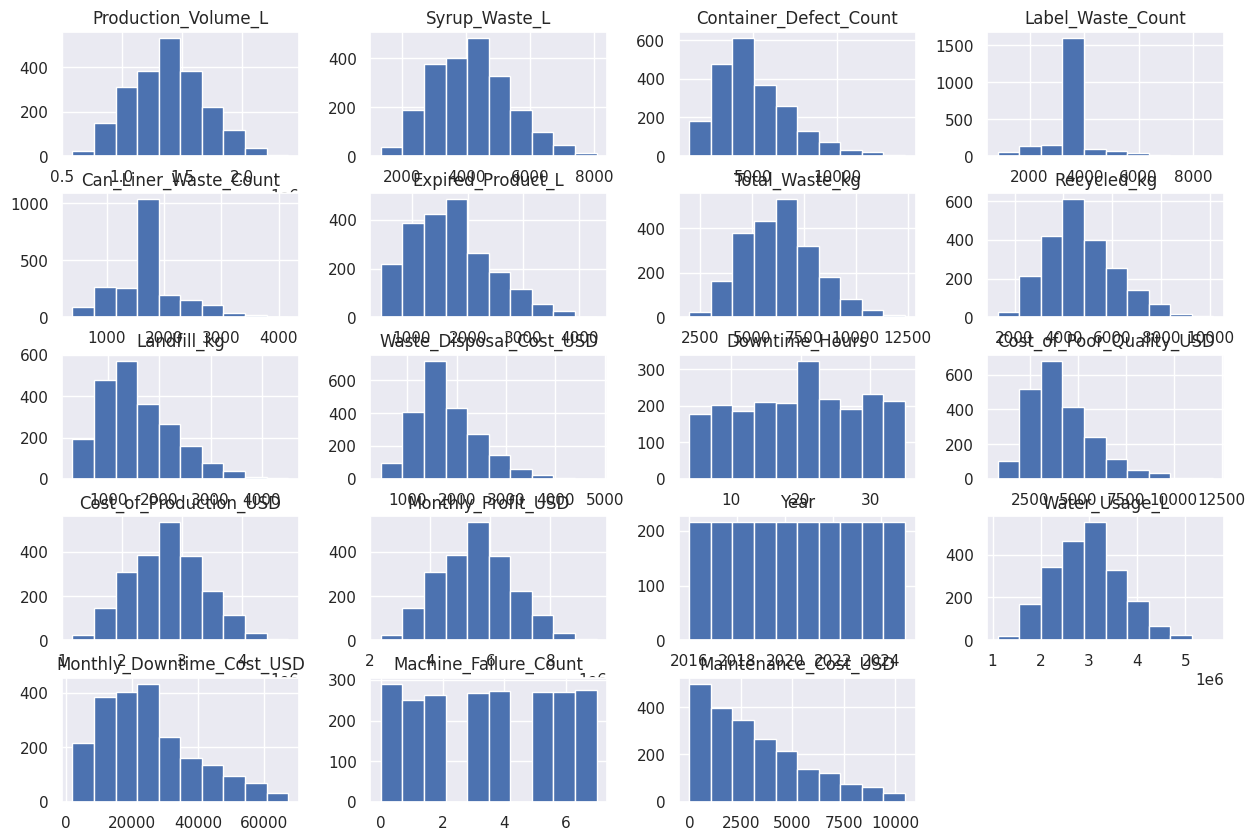

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("Beverage_Waste_Dataset_Final_Cleaned.csv")

# Set visualization style
sns.set_style("darkgrid")

# Plot histograms
data.hist(figsize=(15,10))

plt.show()

array([[<Axes: title={'center': 'Production_Volume_L'}>,
        <Axes: title={'center': 'Syrup_Waste_L'}>,
        <Axes: title={'center': 'Container_Defect_Count'}>,
        <Axes: title={'center': 'Label_Waste_Count'}>],
       [<Axes: title={'center': 'Can_Liner_Waste_Count'}>,
        <Axes: title={'center': 'Expired_Product_L'}>,
        <Axes: title={'center': 'Total_Waste_kg'}>,
        <Axes: title={'center': 'Recycled_kg'}>],
       [<Axes: title={'center': 'Landfill_kg'}>,
        <Axes: title={'center': 'Waste_Disposal_Cost_USD'}>,
        <Axes: title={'center': 'Downtime_Hours'}>,
        <Axes: title={'center': 'Cost_of_Poor_Quality_USD'}>],
       [<Axes: title={'center': 'Cost_of_Production_USD'}>,
        <Axes: title={'center': 'Monthly_Profit_USD'}>,
        <Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Water_Usage_L'}>],
       [<Axes: title={'center': 'Monthly_Downtime_Cost_USD'}>,
        <Axes: title={'center': 'Machine_Failure_Count'}>,
   

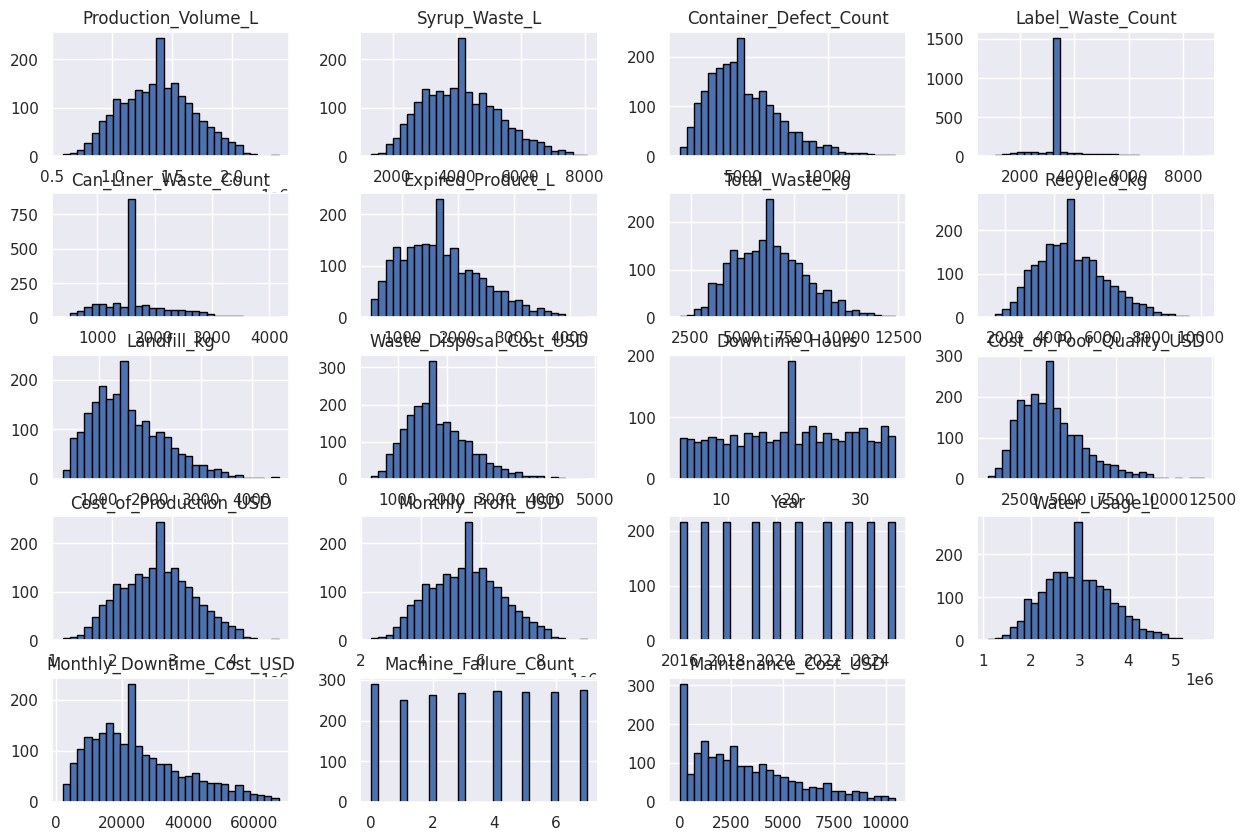

In [46]:
data.hist(bins=30, figsize=(15,10), edgecolor='black')

# HEATMAP

# A Heatmap generally visualizes the correlation(r) that exist between pairs of variables in a dataset. It ranges from -1 to +1

* +1 represent strong positive correlation.This thus means that when one variable increases,the other variable increases as well

* -1 represent strong negative correlation.This indicate that when one variable increases, the other variable decreases.

* 0 means there is no linear relationship

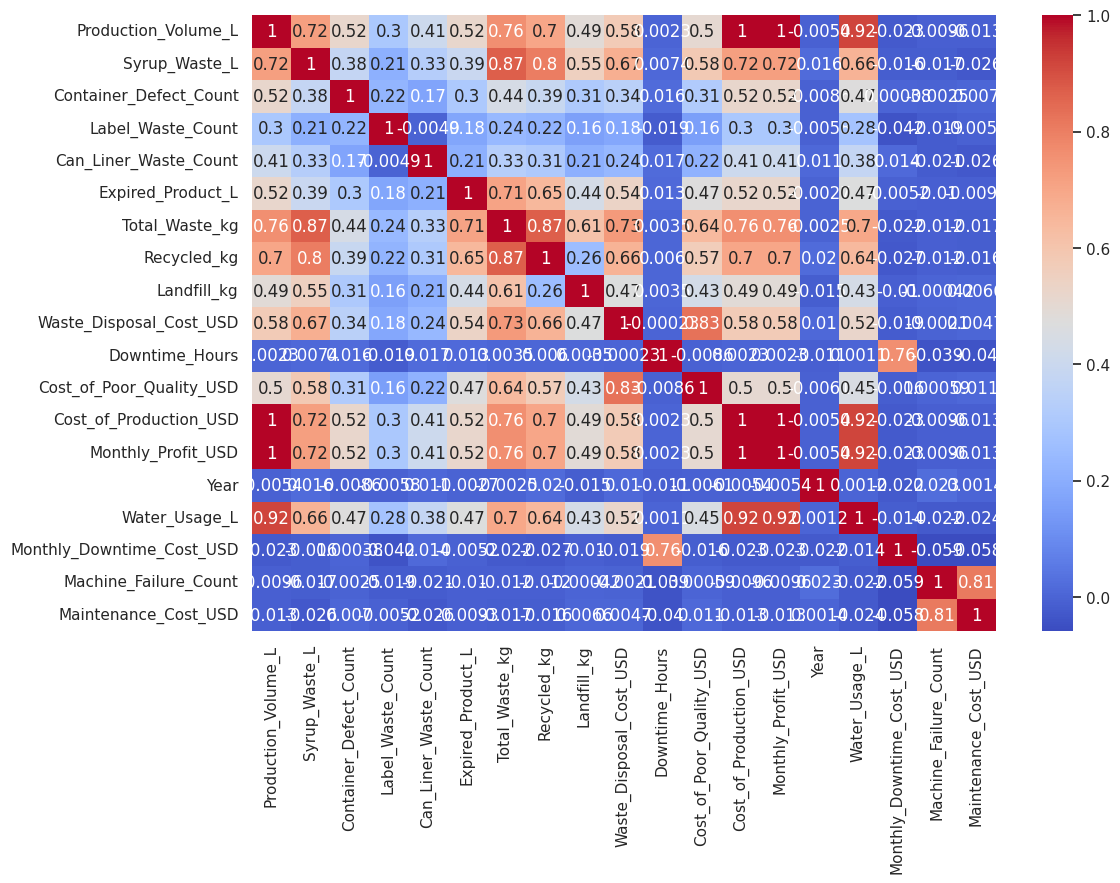

In [47]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [48]:
data.head()

,Month,Plant_ID,Production_Line,Package_Type,Production_Volume_L,Syrup_Waste_L,Container_Defect_Count,Label_Waste_Count,Can_Liner_Waste_Count,Expired_Product_L,Total_Waste_kg,Recycled_kg,Landfill_kg,Waste_Disposal_Cost_USD,Downtime_Hours,Cost_of_Poor_Quality_USD,Cost_of_Production_USD,Monthly_Profit_USD,Year,Water_Usage_L,Monthly_Downtime_Cost_USD,Machine_Failure_Count,Maintenance_Cost_USD
0,2016-01-01,TX01,Line1,Can,1063068.00,4073.00,3377.00,3300.00,2106.00,847.00,3453.00,3016.00,437.00,1045.62,28.30,2042.84,2126136.00,4252272.00,2016,2203412.95,18616.65,3,2052.88
1,2016-01-01,TX01,Line2,Can,1001155.00,2797.00,2538.00,3300.00,1843.00,572.00,3641.00,2670.00,1447.00,1105.47,15.30,2809.82,2002310.00,4004620.00,2016,2271423.45,15693.87,7,6325.43
2,2016-01-01,TX01,Line3,Bottle,963254.00,3165.00,3062.00,3757.00,1654.00,697.00,4184.00,2569.00,1615.00,1186.16,25.20,3343.87,1926508.00,3853016.00,2016,1972218.42,46442.00,7,6923.83
3,2016-02-01,TX01,Line1,Can,943693.00,3176.00,3134.00,3300.00,1132.00,836.00,4323.00,3252.00,1071.00,1324.50,19.20,2398.36,1887386.00,3774772.00,2016,1910214.04,23420.89,0,0.00
4,2016-02-01,TX01,Line2,Can,1114764.00,2924.00,1761.00,3300.00,973.00,910.00,4093.00,2704.00,1389.00,1340.95,27.00,3730.29,2229528.00,4459056.00,2016,2136097.41,44916.26,7,3746.85


In [49]:
from google.colab import files
files.download("Beverage_Waste_Dataset_Final_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
data = pd.read_csv("Beverage_Waste_Dataset_Final_Cleaned.csv")
data.head()

,Month,Plant_ID,Production_Line,Package_Type,Production_Volume_L,Syrup_Waste_L,Container_Defect_Count,Label_Waste_Count,Can_Liner_Waste_Count,Expired_Product_L,Total_Waste_kg,Recycled_kg,Landfill_kg,Waste_Disposal_Cost_USD,Downtime_Hours,Cost_of_Poor_Quality_USD,Cost_of_Production_USD,Monthly_Profit_USD,Year,Water_Usage_L,Monthly_Downtime_Cost_USD,Machine_Failure_Count,Maintenance_Cost_USD
0,2016-01-01,TX01,Line1,Can,1063068.00,4073.00,3377.00,3300.00,2106.00,847.00,3453.00,3016.00,437.00,1045.62,28.30,2042.84,2126136.00,4252272.00,2016,2203412.95,18616.65,3,2052.88
1,2016-01-01,TX01,Line2,Can,1001155.00,2797.00,2538.00,3300.00,1843.00,572.00,3641.00,2670.00,1447.00,1105.47,15.30,2809.82,2002310.00,4004620.00,2016,2271423.45,15693.87,7,6325.43
2,2016-01-01,TX01,Line3,Bottle,963254.00,3165.00,3062.00,3757.00,1654.00,697.00,4184.00,2569.00,1615.00,1186.16,25.20,3343.87,1926508.00,3853016.00,2016,1972218.42,46442.00,7,6923.83
3,2016-02-01,TX01,Line1,Can,943693.00,3176.00,3134.00,3300.00,1132.00,836.00,4323.00,3252.00,1071.00,1324.50,19.20,2398.36,1887386.00,3774772.00,2016,1910214.04,23420.89,0,0.00
4,2016-02-01,TX01,Line2,Can,1114764.00,2924.00,1761.00,3300.00,973.00,910.00,4093.00,2704.00,1389.00,1340.95,27.00,3730.29,2229528.00,4459056.00,2016,2136097.41,44916.26,7,3746.85


**UNIVARIATE ANALYSIS**

In [51]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [52]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [53]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [54]:
### Function to plot distributions


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

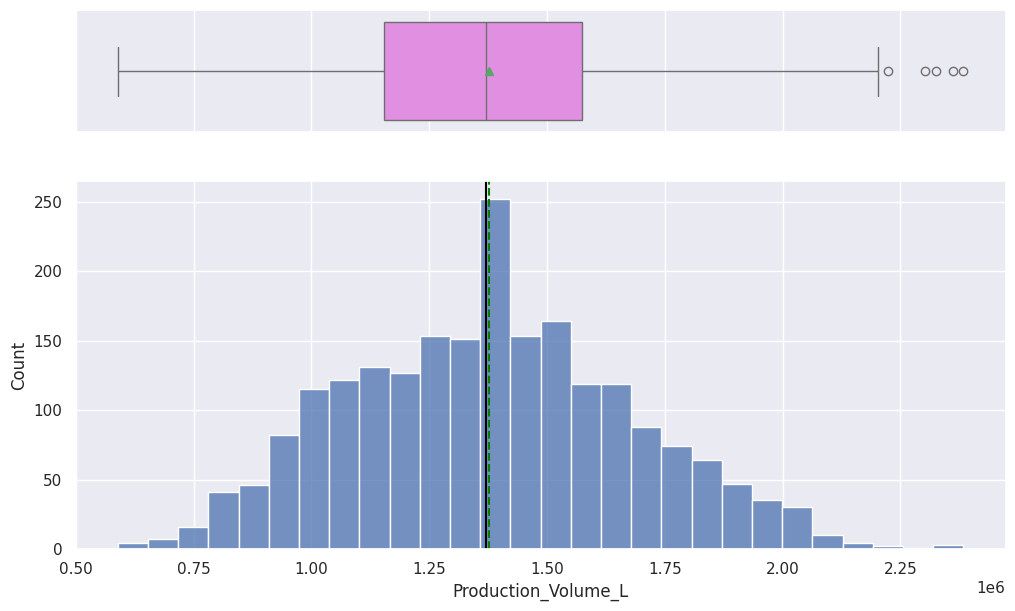

In [55]:
histogram_boxplot(data,"Production_Volume_L")

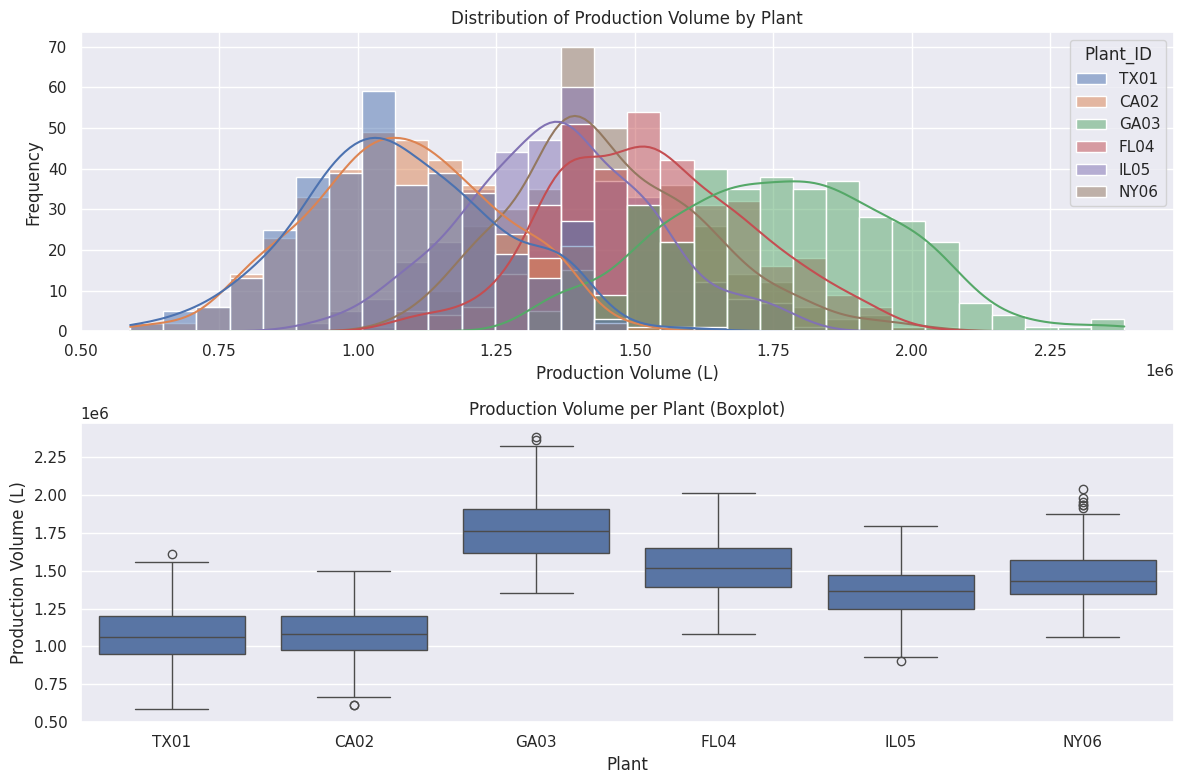

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")

# Load dataset
data = pd.read_csv("Beverage_Waste_Dataset_Final_Cleaned.csv")

# Create figure
plt.figure(figsize=(12,8))

# Histogram (top)
plt.subplot(2,1,1)
sns.histplot(data=data, x='Production_Volume_L', hue='Plant_ID', bins=30, kde=True)
plt.title("Distribution of Production Volume by Plant")
plt.xlabel("Production Volume (L)")
plt.ylabel("Frequency")

# Boxplot (bottom)
plt.subplot(2,1,2)
sns.boxplot(x='Plant_ID', y='Production_Volume_L', data=data)
plt.title("Production Volume per Plant (Boxplot)")
plt.xlabel("Plant")
plt.ylabel("Production Volume (L)")

plt.tight_layout()
plt.show()

<Axes: xlabel='Production_Volume_L', ylabel='Count'>

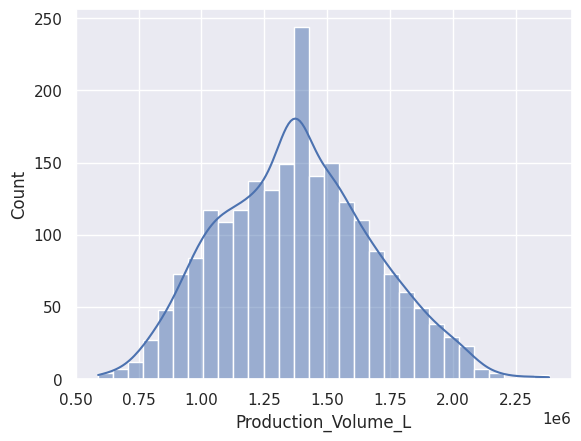

In [57]:
sns.histplot(data=data, x='Production_Volume_L', bins=30, kde=True)

**INTERPRETATION**

* The histogram and boxplot provided above presents  a comprehensive visualization of production volume across the 6 different plants under R3 and Son Beverages.
* The histogram reveals the distribution and variability of production levels, while the boxplot highlights differences in median production and the presence of outliers.
* The Median production volume is about 1.37million Litteres
* The Box plot for production volume shows that it is evenly skewed with outliers on the right except for GA03 which is slightly right skewed.
* TX01 ans CA02 had the least and almost thesame production volume followed by IL05 and NY06.
* GAO3 recorded the highest productionvolume followed by FL04.
* NY06 has few outliers on the right followed by GA03 and TX01.

# PRODUCTION VOLUME ON DIFFERENT LINES ACROSS ALL 6 PLANTS

In [58]:
print(data.Package_Type)

0          Can
1          Can
2       Bottle
3          Can
4          Can
         ...  
2155       Can
2156    Bottle
2157       Can
2158       Can
2159    Bottle
Name: Package_Type, Length: 2160, dtype: object


In [59]:
print(data.columns.tolist())

['Month', 'Plant_ID', 'Production_Line', 'Package_Type', 'Production_Volume_L', 'Syrup_Waste_L', 'Container_Defect_Count', 'Label_Waste_Count', 'Can_Liner_Waste_Count', 'Expired_Product_L', 'Total_Waste_kg', 'Recycled_kg', 'Landfill_kg', 'Waste_Disposal_Cost_USD', 'Downtime_Hours', 'Cost_of_Poor_Quality_USD', 'Cost_of_Production_USD', 'Monthly_Profit_USD', 'Year', 'Water_Usage_L', 'Monthly_Downtime_Cost_USD', 'Machine_Failure_Count', 'Maintenance_Cost_USD']


In [60]:
data.columns = data.columns.str.strip()

In [61]:
['Month','Plant_ID','Production_Volume_L','Package_Type']

['Month', 'Plant_ID', 'Production_Volume_L', 'Package_Type']

<Axes: xlabel='Production_Volume_L', ylabel='Count'>

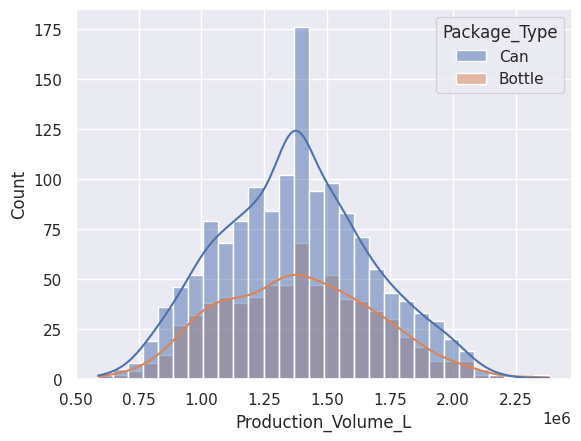

In [62]:
sns.histplot(data=data, x='Production_Volume_L', hue='Package_Type', bins=30, kde=True)

In [63]:
import numpy as np

data['Line'] = np.random.choice(['Line 1','Line 2','Line 3'], size=len(data))

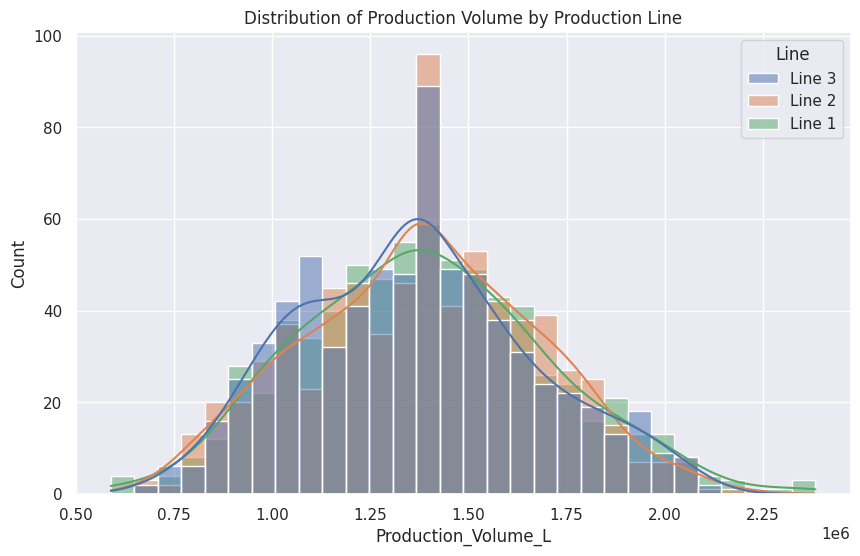

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.histplot(data=data, x='Production_Volume_L', hue='Line', bins=30, kde=True)

plt.title("Distribution of Production Volume by Production Line")
plt.show()

In [65]:
print(data.columns.tolist())

['Month', 'Plant_ID', 'Production_Line', 'Package_Type', 'Production_Volume_L', 'Syrup_Waste_L', 'Container_Defect_Count', 'Label_Waste_Count', 'Can_Liner_Waste_Count', 'Expired_Product_L', 'Total_Waste_kg', 'Recycled_kg', 'Landfill_kg', 'Waste_Disposal_Cost_USD', 'Downtime_Hours', 'Cost_of_Poor_Quality_USD', 'Cost_of_Production_USD', 'Monthly_Profit_USD', 'Year', 'Water_Usage_L', 'Monthly_Downtime_Cost_USD', 'Machine_Failure_Count', 'Maintenance_Cost_USD', 'Line']


In [66]:
import numpy as np
data['Line'] = np.random.choice(['Line 1','Line 2','Line 3'], size=len(data))

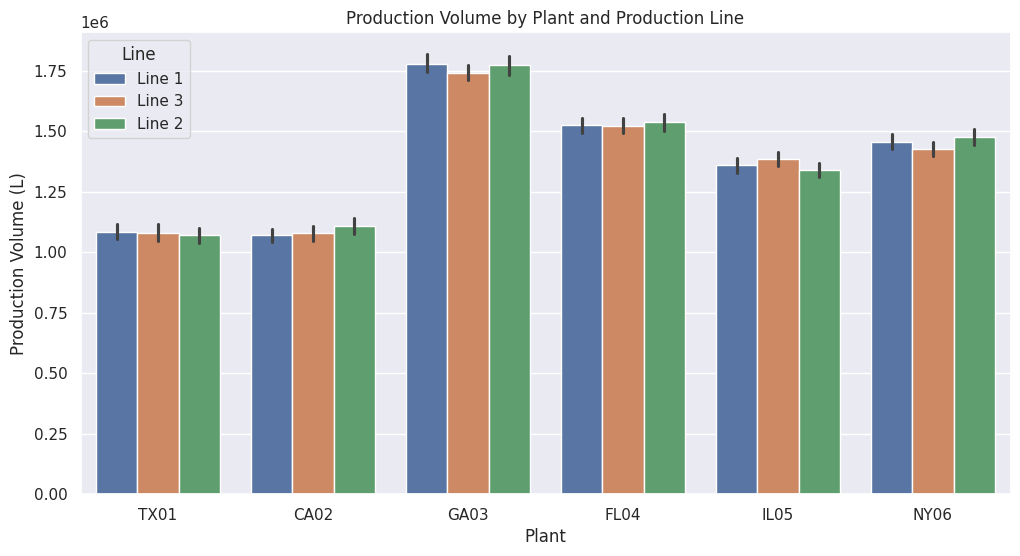

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")

plt.figure(figsize=(12,6))

sns.barplot(
    data=data,
    x='Plant_ID',
    y='Production_Volume_L',
    hue='Line'
)

plt.title("Production Volume by Plant and Production Line")
plt.xlabel("Plant")
plt.ylabel("Production Volume (L)")

plt.show()

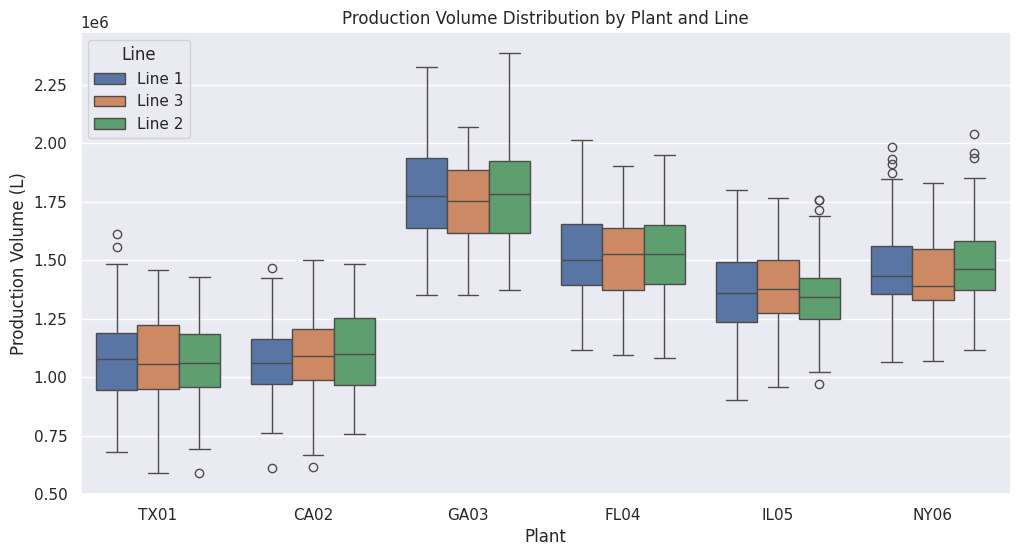

In [68]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=data,
    x='Plant_ID',
    y='Production_Volume_L',
    hue='Line'
)

plt.title("Production Volume Distribution by Plant and Line")
plt.xlabel("Plant")
plt.ylabel("Production Volume (L)")

plt.show()

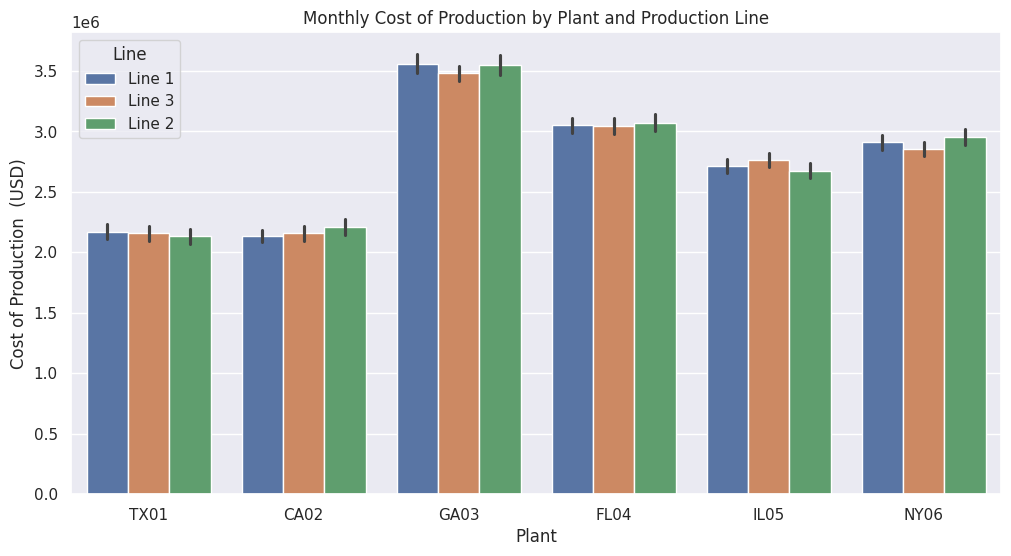

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")

plt.figure(figsize=(12,6))

sns.barplot(
    data=data,
    x='Plant_ID',
    y='Cost_of_Production_USD',
    hue='Line'
)

plt.title("Monthly Cost of Production by Plant and Production Line")
plt.xlabel("Plant")
plt.ylabel("Cost of Production  (USD)")

plt.show()

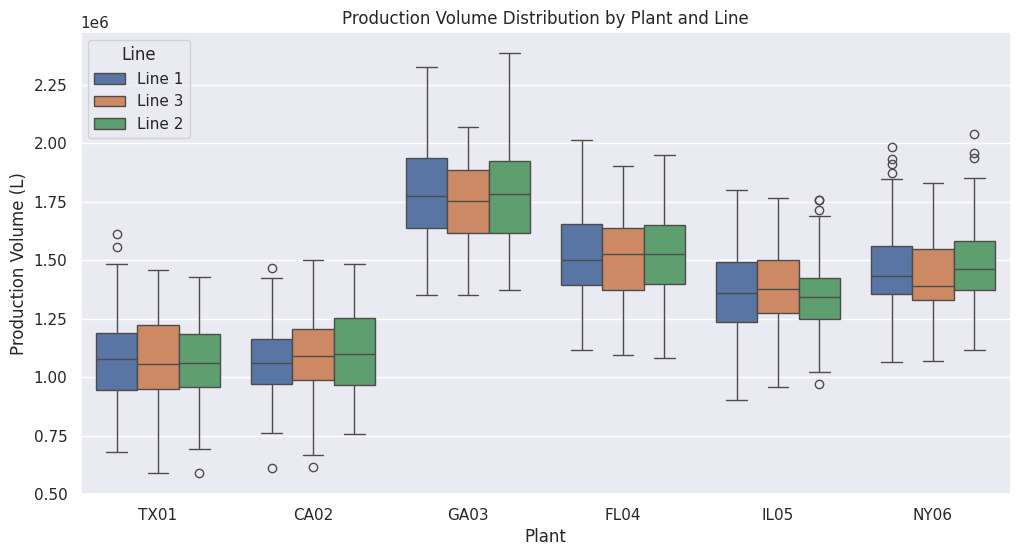

In [70]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=data,
    x='Plant_ID',
    y='Production_Volume_L',
    hue='Line'
)

plt.title("Production Volume Distribution by Plant and Line")
plt.xlabel("Plant")
plt.ylabel("Production Volume (L)")

plt.show()

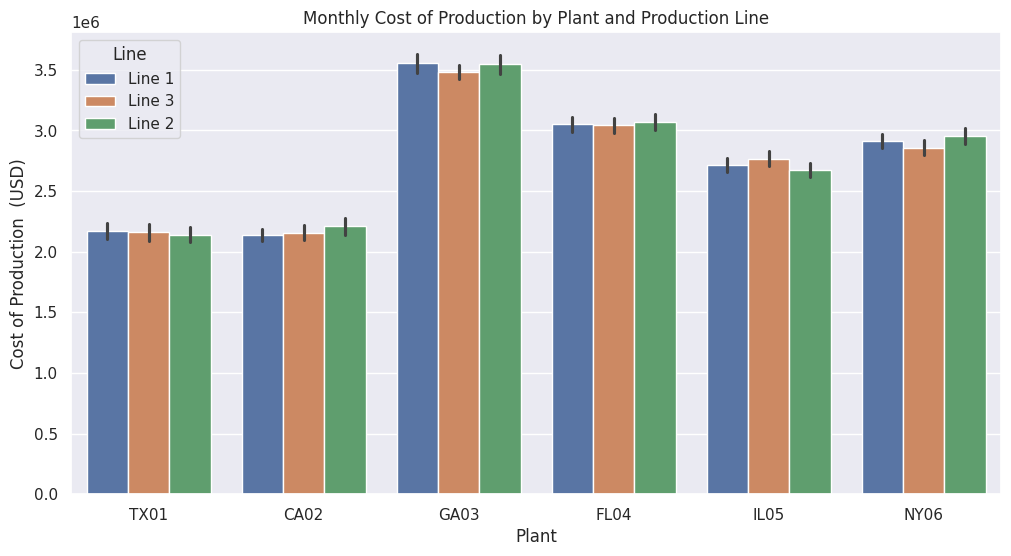

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")

plt.figure(figsize=(12,6))

sns.barplot(
    data=data,
    x='Plant_ID',
    y='Cost_of_Production_USD',
    hue='Line'
)

plt.title("Monthly Cost of Production by Plant and Production Line")
plt.xlabel("Plant")
plt.ylabel("Cost of Production  (USD)")

plt.show()

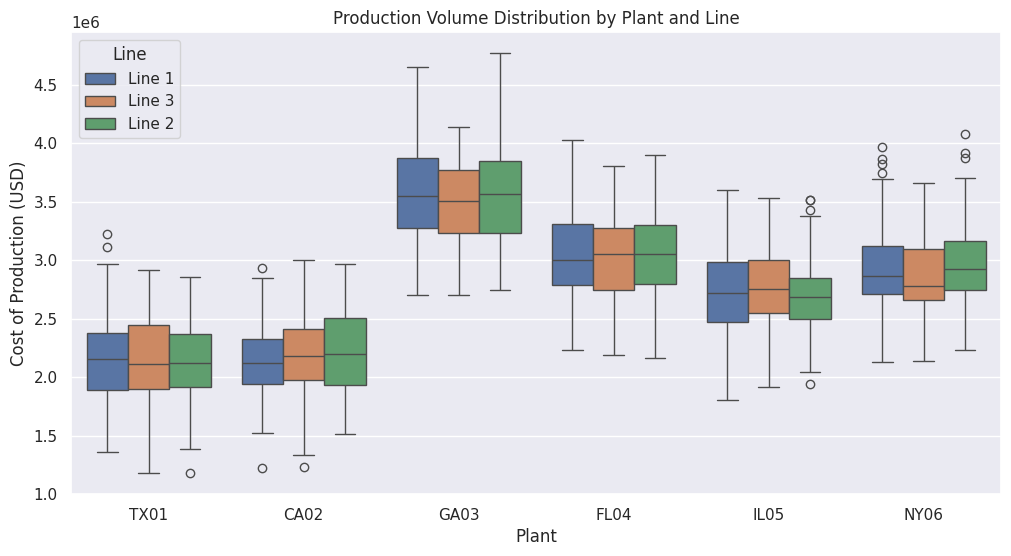

In [72]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=data,
    x='Plant_ID',
    y='Cost_of_Production_USD',
    hue='Line'
)

plt.title("Production Volume Distribution by Plant and Line")
plt.xlabel("Plant")
plt.ylabel("Cost of Production (USD)")

plt.show()